#Imports

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


#Download Dataset

In [2]:
!wget -q https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip
!unzip -q -o jena_climate_2009_2016.csv.zip
df = pd.read_csv("jena_climate_2009_2016.csv")
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


#Preprocessing

In [3]:
n_rows = len(df) // 6 * 6
df = df.iloc[:n_rows]

df = df.groupby(df.index // 6).mean(numeric_only=True)
df = df.reset_index(drop=True)

feature_cols = [
    "T (degC)",
    "p (mbar)",
    "rh (%)",
    "wv (m/s)",
    "max. wv (m/s)",
    "wd (deg)"
]

target_col = "T (degC)"

features = df[feature_cols].values.astype(np.float32)
target = df[target_col].values.astype(np.float32)

n = len(features)

train_end = int(n * 0.7)
val_end = int(n * 0.85)

feature_mean = features[:train_end].mean(axis=0)
feature_std = features[:train_end].std(axis=0)
feature_std[feature_std == 0] = 1

features_norm = (features - feature_mean) / feature_std

target_mean = target[:train_end].mean()
target_std = target[:train_end].std()
if target_std == 0:
    target_std = 1

target_norm = (target - target_mean) / target_std

#Build sliding windows

In [4]:
INPUT_LEN = 720
OUTPUT_LEN = 24

def make_windows(features, target, input_len, output_len):
    X = []
    Y = []

    for i in range(len(features) - input_len - output_len + 1):
        X.append(features[i:i + input_len])
        Y.append(target[i + input_len:i + input_len + output_len])

    return np.array(X), np.array(Y)

train_features = features_norm[:train_end]
val_features = features_norm[train_end:val_end]
test_features = features_norm[val_end:]

train_target = target_norm[:train_end]
val_target = target_norm[train_end:val_end]
test_target = target_norm[val_end:]

X_train, Y_train = make_windows(train_features, train_target, INPUT_LEN, OUTPUT_LEN)
X_val, Y_val = make_windows(val_features, val_target, INPUT_LEN, OUTPUT_LEN)
X_test, Y_test = make_windows(test_features, test_target, INPUT_LEN, OUTPUT_LEN)

print(X_train.shape, Y_train.shape)
print(X_val.shape, Y_val.shape)
print(X_test.shape, Y_test.shape)

(48320, 720, 6) (48320, 24)
(9771, 720, 6) (9771, 24)
(9771, 720, 6) (9771, 24)


#Dataset and DataLoader

In [5]:
from torch.utils.data import Dataset, DataLoader

class WeatherDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

BATCH_SIZE = 64

train_loader = DataLoader(WeatherDataset(X_train, Y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(WeatherDataset(X_val, Y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(WeatherDataset(X_test, Y_test), batch_size=BATCH_SIZE, shuffle=False)

xb, yb = next(iter(train_loader))
print(xb.shape, yb.shape)

torch.Size([64, 720, 6]) torch.Size([64, 24])


#Sinusoidal positional encoding

In [6]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len, :]

#Multi-head self-attention

In [7]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, x):
        batch_size, seq_len, d_model = x.shape

        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        Q = Q.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)

        scores = (Q @ K.transpose(-2, -1)) / np.sqrt(self.d_k)
        attn_weights = torch.softmax(scores, dim=-1)
        attn_out = attn_weights @ V

        attn_out = attn_out.transpose(1, 2).contiguous().view(batch_size, seq_len, d_model)
        return self.W_o(attn_out)

#Encoder block

In [8]:
class EncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.2):
        super().__init__()
        self.attn = MultiHeadSelfAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout1 = nn.Dropout(dropout)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
        )
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x):
        attn_out = self.attn(x)
        x = self.norm1(x + self.dropout1(attn_out))

        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout2(ffn_out))
        return x

#Full encoder-only Transformer forecaster

In [9]:
class TransformerForecaster(nn.Module):
    def __init__(self, input_size, d_model=64, num_heads=4, d_ff=None, num_layers=3, output_len=24, max_len=1000, dropout=0.1):
        super().__init__()

        if d_ff is None:
            d_ff = d_model * 4

        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len=max_len)
        self.input_dropout = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([EncoderBlock(d_model, num_heads, d_ff) for _ in range(num_layers)])
        self.output_head = nn.Linear(d_model, output_len)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_enc(x)
        x = self.input_dropout(x)
        for block in self.blocks:
            x = block(x)
        x = x[:, -1, :]
        return self.output_head(x)

model = TransformerForecaster(
    input_size=len(feature_cols),
    d_model=64,
    num_heads=4,
    num_layers=3,
    output_len=OUTPUT_LEN,
    max_len=INPUT_LEN
).to(device)


#Train and evaluate functions

In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, total = 0.0, 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        total += xb.size(0)

    return total_loss / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total = 0.0, 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = model(xb)
        loss = criterion(preds, yb)

        total_loss += loss.item() * xb.size(0)
        total += xb.size(0)

    return total_loss / total

def set_lr(optimizer, lr):
    for param_group in optimizer.param_groups:
        param_group["lr"] = lr

#Training loop with LR warmup

In [11]:
TARGET_LR = 5e-4
WEIGHT_DECAY = 5e-4
EPOCHS = 25
WARMUP_EPOCHS = 5

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=TARGET_LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

history = {"train_loss": [], "val_loss": []}
best_val_loss = float("inf")
best_state = None

for epoch in range(1, EPOCHS + 1):
    if epoch <= WARMUP_EPOCHS:
        warmup_lr = TARGET_LR * (epoch / WARMUP_EPOCHS)
        set_lr(optimizer, warmup_lr)

    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = evaluate(model, val_loader, criterion, device)

    if epoch > WARMUP_EPOCHS:
        scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    print(f"Epoch {epoch}/{EPOCHS} | train_loss {train_loss:.4f} | val_loss {val_loss:.4f}")

print("Best validation loss:", best_val_loss)

Epoch 1/25 | train_loss 0.2936 | val_loss 0.4598
Epoch 2/25 | train_loss 0.1642 | val_loss 0.5394
Epoch 3/25 | train_loss 0.1151 | val_loss 0.3806
Epoch 4/25 | train_loss 0.1049 | val_loss 0.4053
Epoch 5/25 | train_loss 0.1003 | val_loss 0.2993
Epoch 6/25 | train_loss 0.0965 | val_loss 0.2132
Epoch 7/25 | train_loss 0.0942 | val_loss 0.2411
Epoch 8/25 | train_loss 0.0922 | val_loss 0.2161
Epoch 9/25 | train_loss 0.0912 | val_loss 0.1985
Epoch 10/25 | train_loss 0.0898 | val_loss 0.2128
Epoch 11/25 | train_loss 0.0887 | val_loss 0.2122
Epoch 12/25 | train_loss 0.0886 | val_loss 0.2308
Epoch 13/25 | train_loss 0.0864 | val_loss 0.2217
Epoch 14/25 | train_loss 0.0856 | val_loss 0.1846
Epoch 15/25 | train_loss 0.0853 | val_loss 0.1848
Epoch 16/25 | train_loss 0.0851 | val_loss 0.1896
Epoch 17/25 | train_loss 0.0851 | val_loss 0.2030
Epoch 18/25 | train_loss 0.0839 | val_loss 0.1819
Epoch 19/25 | train_loss 0.0835 | val_loss 0.2443
Epoch 20/25 | train_loss 0.0835 | val_loss 0.1804
Epoch 21/

#Loss curves

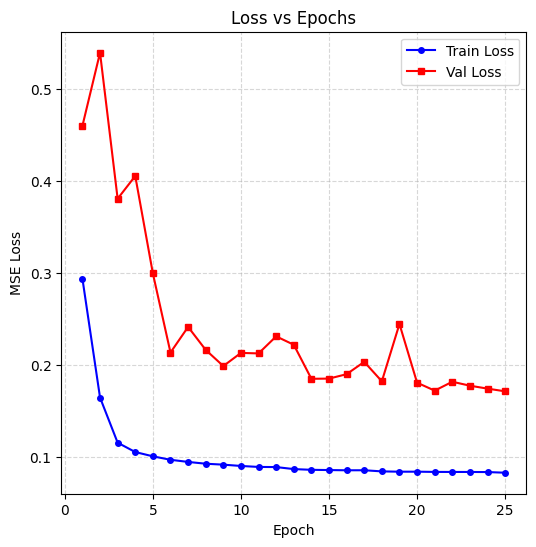

In [12]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(6, 6))
plt.plot(epochs_range, history["train_loss"], "b-o", markersize=4, label="Train Loss")
plt.plot(epochs_range, history["val_loss"], "r-s", markersize=4, label="Val Loss")
plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

#Prediction vs Actual

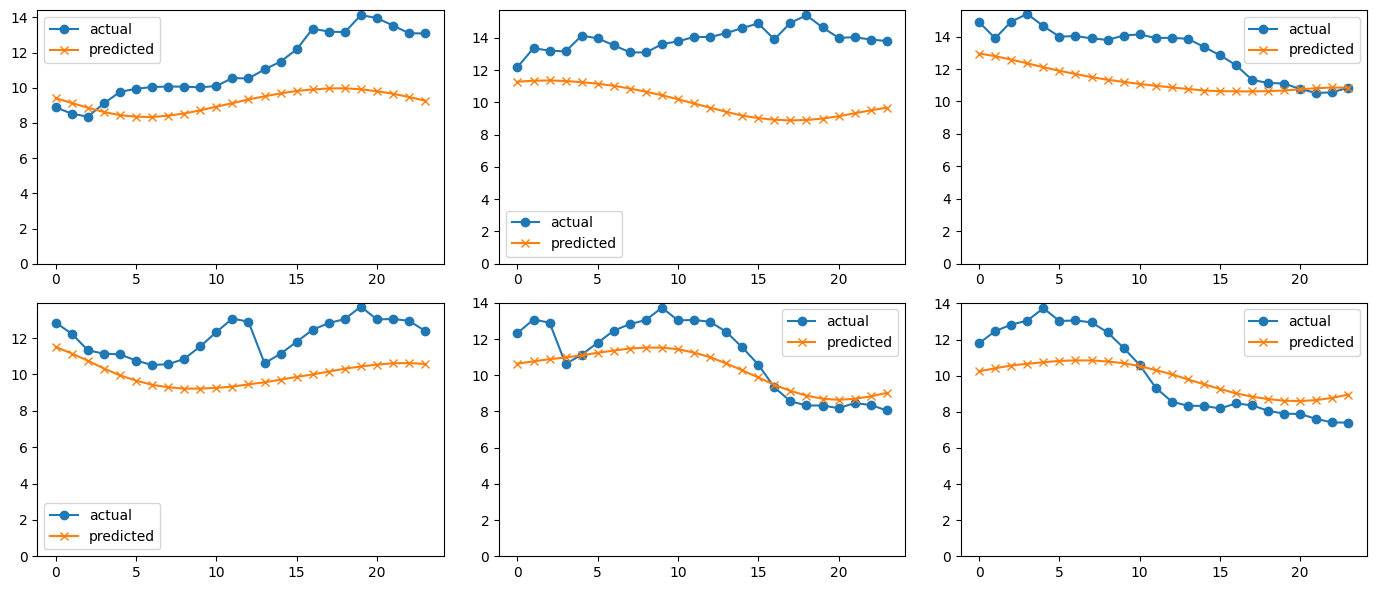

In [17]:
model.eval()
xb, yb = next(iter(test_loader))
xb, yb = xb.to(device), yb.to(device)
with torch.no_grad():
    preds = model(xb)

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for ax, idx in zip(axes.flat, [0, 15, 30, 45, 55, 60]):
    pred_denorm = preds[idx].cpu().numpy() * target_std + target_mean
    true_denorm = yb[idx].cpu().numpy() * target_std + target_mean
    ax.plot(true_denorm, label="actual", marker="o")
    ax.plot(pred_denorm, label="predicted", marker="x")
    ax.set_ylim(bottom=0)
    ax.legend()
plt.tight_layout()
plt.show()

#Saving Model Weights

In [18]:
torch.save(best_state, 'model_weights.pth')
print("Model weights saved to best_model.pth")

Model weights saved to best_model.pth
